# PNA — Fixed Architecture, Batch of Feature Configurations (HI-Small)

- **Question:** what do engineered edge features add when the GNN architecture is held *exactly* fixed?
- **Knobs per config:** `mp` = edge features in message passing (`none` / `base` / `full`), `readout` = edge features at the classifier (`base` / `full` / `gfp`). Direction and temporal sampling are fixed per batch.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`. This notebook only sets `OPERATOR`, the config batch and paths.
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must be **427,265** in every run.

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 170.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 182.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 82.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 86.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 166.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 174 (delta 63), reused 141 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 5.74 MiB | 14.87 MiB/s, done.
Resolving deltas: 100% (63/63), done.
ce0d432 (HEAD -> main, origin/main, origin/HEAD) Strip stale ipywidgets state from PNA_fixed_architecture.ipynb metadata (5 MB -> 16 KB, Kaggle's 1 MB source limit)


## 1. Configuration

- The only cell that differs between operator notebooks (`GIN_` / `PNA_` / `GAT_`).
- `CONFIGS`: one dict per run of this batch; run numbers refer to `EXPERIMENTS.md`.
- `OUT_ROOT` mirrors `Outputs/PNA/` in the repo; the zip in section 6 is what gets committed (minus `best.pt`).

In [3]:
OPERATOR = 'pna'

# knob configs of this batch — one dict per run
CONFIGS = [
    dict(mp='none', readout='base'),   # PNA-1 — topology alone, the reference point
    dict(mp='base', readout='base'),   # PNA-2 — edge features inside message passing
    dict(mp='none', readout='full'),   # PNA-3 — GFP only at the decision layer
    dict(mp='full', readout='full'),   # PNA-4 — GFP everywhere
    dict(mp='base', readout='full'),   # PNA-5 — GFP at the decision layer only
    dict(mp='base', readout='gfp'),    # PNA-6 — are raw features redundant once message passing has used them?
    dict(mp='none', readout='gfp'),    # PNA-7 — GFP alone vs baseline alone (compare with PNA-1)
]
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
OUT_ROOT    = '/kaggle/working/Outputs/PNA'      # mirrors Outputs/PNA/ in the repo

import gnn_core as core
os.makedirs(OUT_ROOT, exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 61, full = all 81.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR)

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`.
- `PNAConv`: mean / max / min / std of the messages × identity / amplification / attenuation degree scalers (12 views → MLP → 128), scalers calibrated on the training-graph in-degree histogram; `mp ≠ none` adds `edge_encoder(edge_dim)` and widens the message MLP's input.
- Between configs only `edge_encoder`, the message MLP's first `Linear` and the readout's first `Linear` change width; `invariant_params` counts the rest and must be 427,265.

In [5]:
cfg = CONFIGS[0]
model = core.build_model(OPERATOR, node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional', core.in_degree_histogram(graphs['train']))
print(model)
print(f'params {core.count_params(model):,} | invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=6, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): PNAConv(128, 128, towers=1, edge_dim=None)
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=276, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
params 561,537 | invariant_params 427,265   (config {'mp': 'none', 'readout': 'base'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== pna_mp-none_readout-base_dir-in ===
MP edge features: 0 | readout edge features: 20
total params: 561,537 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0148 / 0.0234 | F1 0.4798 / 0.4845 @ 0.413 | PR-AUC 0.4077 / 0.3915 | 148s | RAM 6.7GB   (train / val)
best validation F1 0.4903 at epoch 12 (threshold 0.490)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4674  0.4909  0.4523
precision          0.6218  0.7612  0.5997
recall             0.3744  0.3623  0.3631
pr_auc             0.4044  0.4051  0.3892
roc_auc            0.9774  0.9752  0.9757
precision_at_5pct  0.0129  0.0180  0.0193
recall_at_5pct     0.8524  0.8466  0.8556
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-none_readout-base_dir-in/predictions.csv


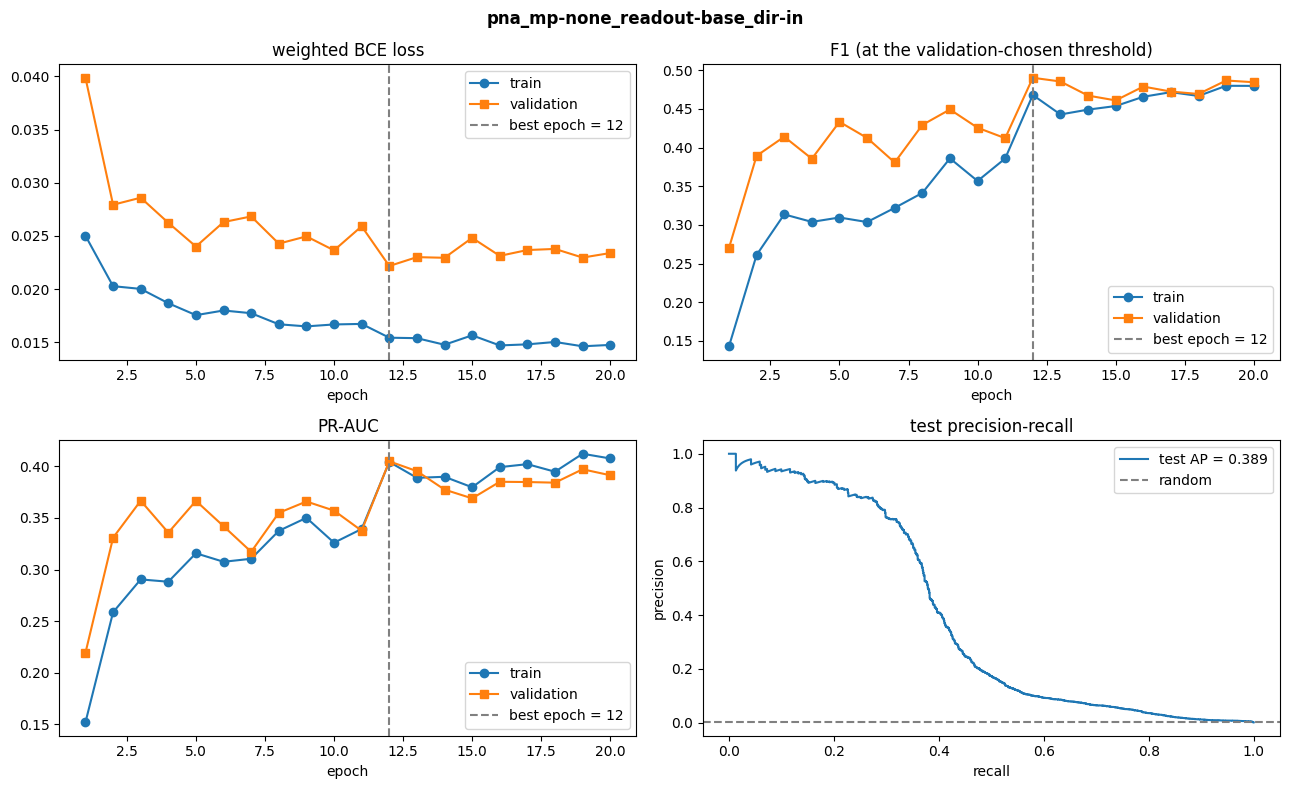

=== pna_mp-base_readout-base_dir-in ===
MP edge features: 20 | readout edge features: 20
total params: 599,681 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0103 / 0.0167 | F1 0.5991 / 0.6266 @ 0.634 | PR-AUC 0.5707 / 0.5828 | 185s | RAM 7.8GB   (train / val)
best validation F1 0.6519 at epoch 14 (threshold 0.632)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5847  0.6508  0.6138
precision          0.7790  0.8439  0.7764
recall             0.4680  0.5296  0.5074
pr_auc             0.5468  0.6052  0.5783
roc_auc            0.9894  0.9851  0.9849
precision_at_5pct  0.0137  0.0186  0.0198
recall_at_5pct     0.9073  0.8725  0.8810
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-base_readout-base_dir-in/predictions.csv


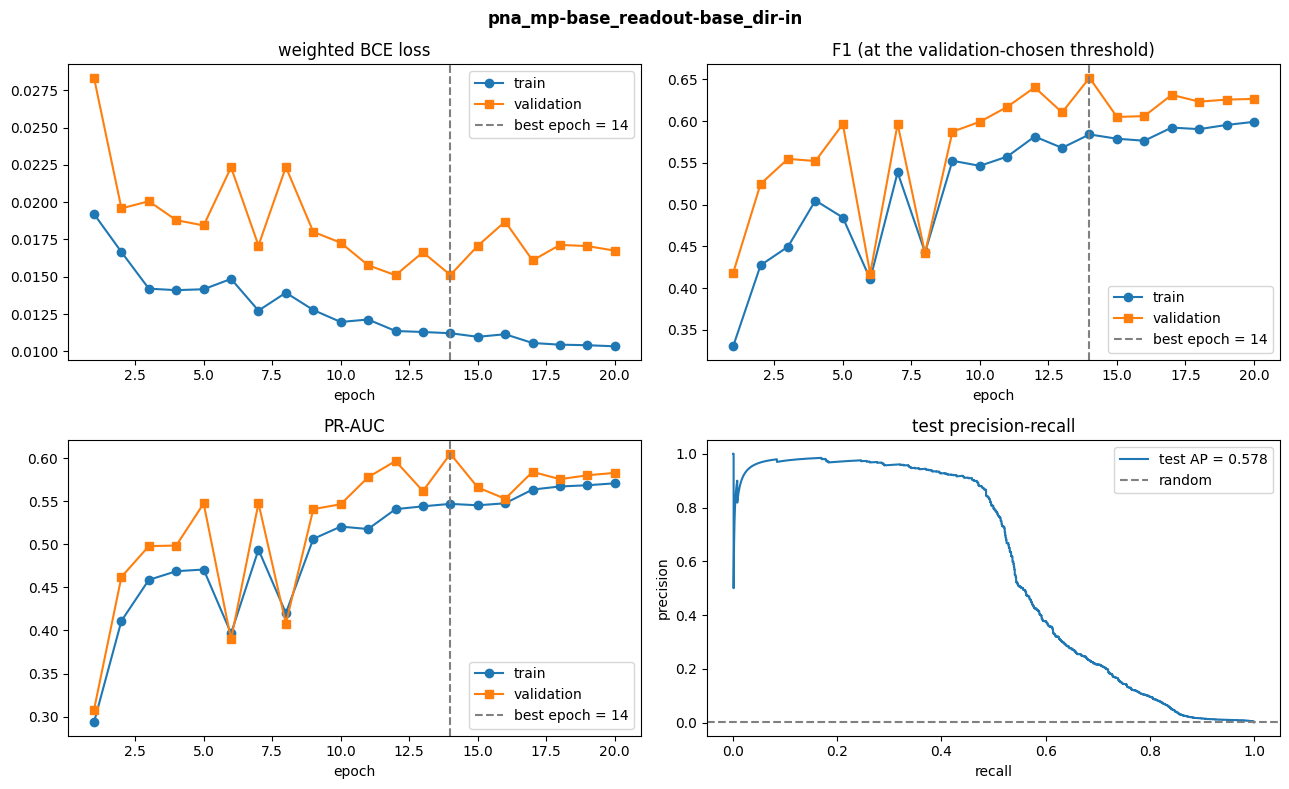

=== pna_mp-none_readout-full_dir-in ===
MP edge features: 0 | readout edge features: 81
total params: 569,345 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0137 / 0.0199 | F1 0.4617 / 0.5511 @ 0.393 | PR-AUC 0.4413 / 0.4831 | 148s | RAM 7.9GB   (train / val)
best validation F1 0.5737 at epoch 14 (threshold 0.453)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4949  0.5737  0.5117
precision          0.6376  0.8210  0.6797
recall             0.4044  0.4409  0.4103
pr_auc             0.4438  0.5076  0.4720
roc_auc            0.9856  0.9823  0.9814
precision_at_5pct  0.0134  0.0184  0.0195
recall_at_5pct     0.8864  0.8641  0.8653
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-none_readout-full_dir-in/predictions.csv


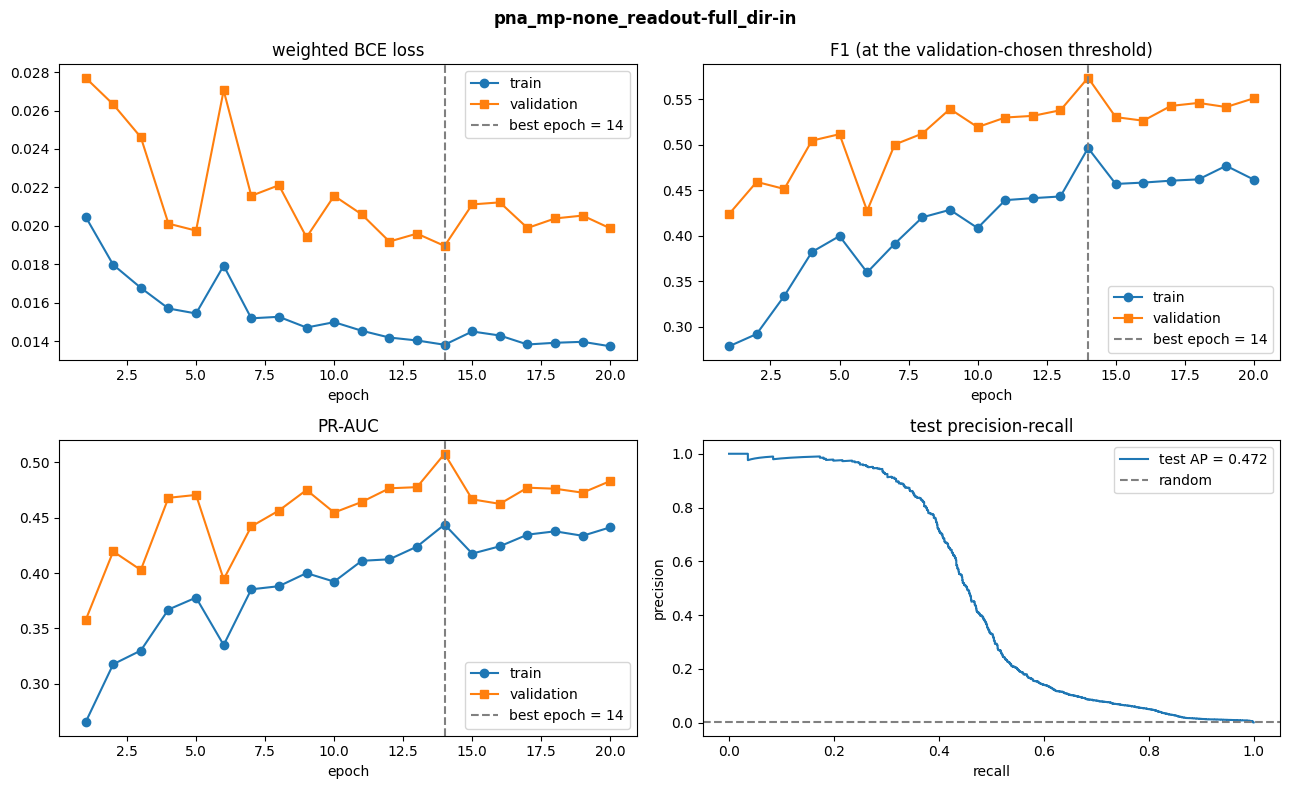

=== pna_mp-full_readout-full_dir-in ===
MP edge features: 81 | readout edge features: 81
total params: 623,105 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0089 / 0.0188 | F1 0.6135 / 0.6348 @ 0.706 | PR-AUC 0.6218 / 0.5834 | 230s | RAM 11.7GB   (train / val)
best validation F1 0.6482 at epoch 15 (threshold 0.699)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5977  0.6482  0.6167
precision          0.8394  0.8943  0.8556
recall             0.4641  0.5083  0.4821
pr_auc             0.5845  0.6056  0.5754
roc_auc            0.9932  0.9845  0.9841
precision_at_5pct  0.0144  0.0185  0.0200
recall_at_5pct     0.9560  0.8697  0.8880
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-full_readout-full_dir-in/predictions.csv


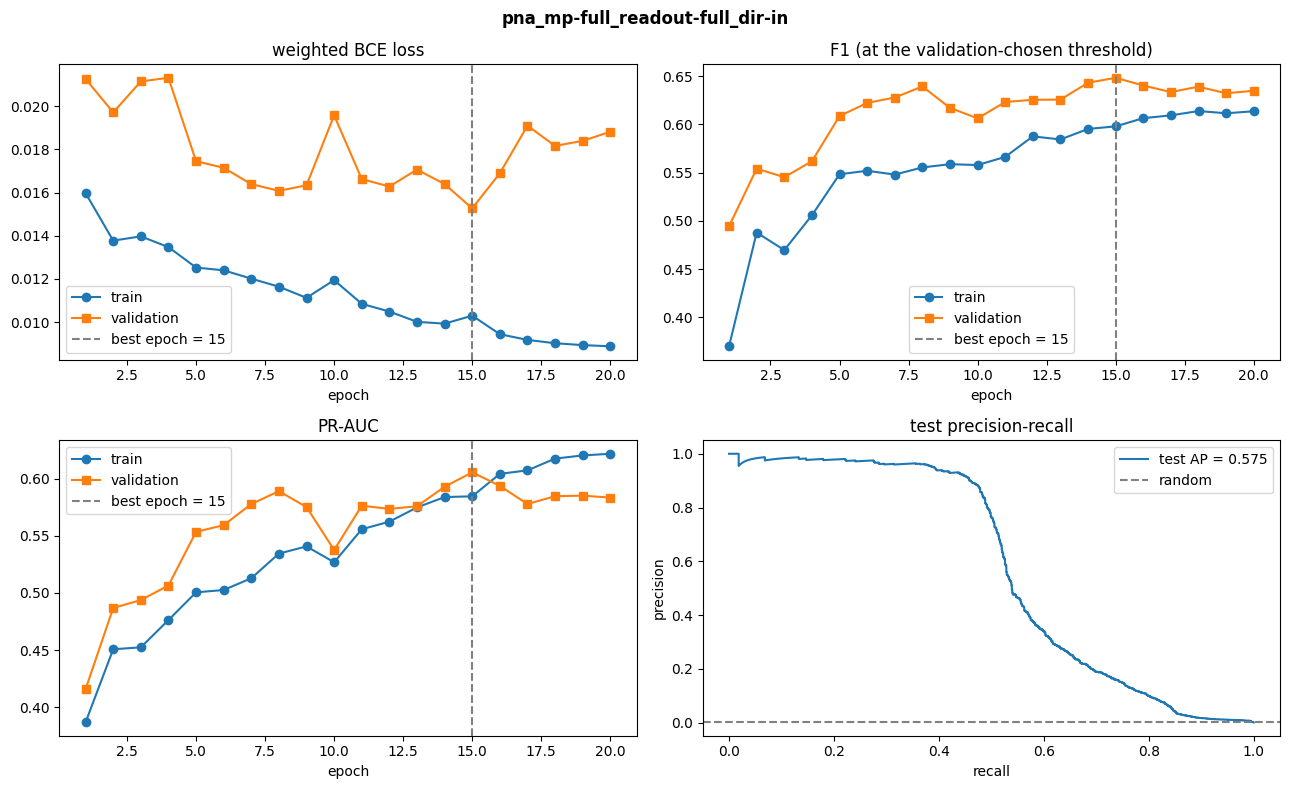

=== pna_mp-base_readout-full_dir-in ===
MP edge features: 20 | readout edge features: 81
total params: 607,489 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0102 / 0.0159 | F1 0.5945 / 0.6394 @ 0.639 | PR-AUC 0.5748 / 0.5981 | 184s | RAM 8.9GB   (train / val)
best validation F1 0.6481 at epoch 15 (threshold 0.711)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5872  0.6481  0.6111
precision          0.8192  0.8719  0.8003
recall             0.4576  0.5157  0.4943
pr_auc             0.5597  0.6103  0.5739
roc_auc            0.9911  0.9859  0.9859
precision_at_5pct  0.0140  0.0188  0.0201
recall_at_5pct     0.9269  0.8826  0.8924
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-base_readout-full_dir-in/predictions.csv


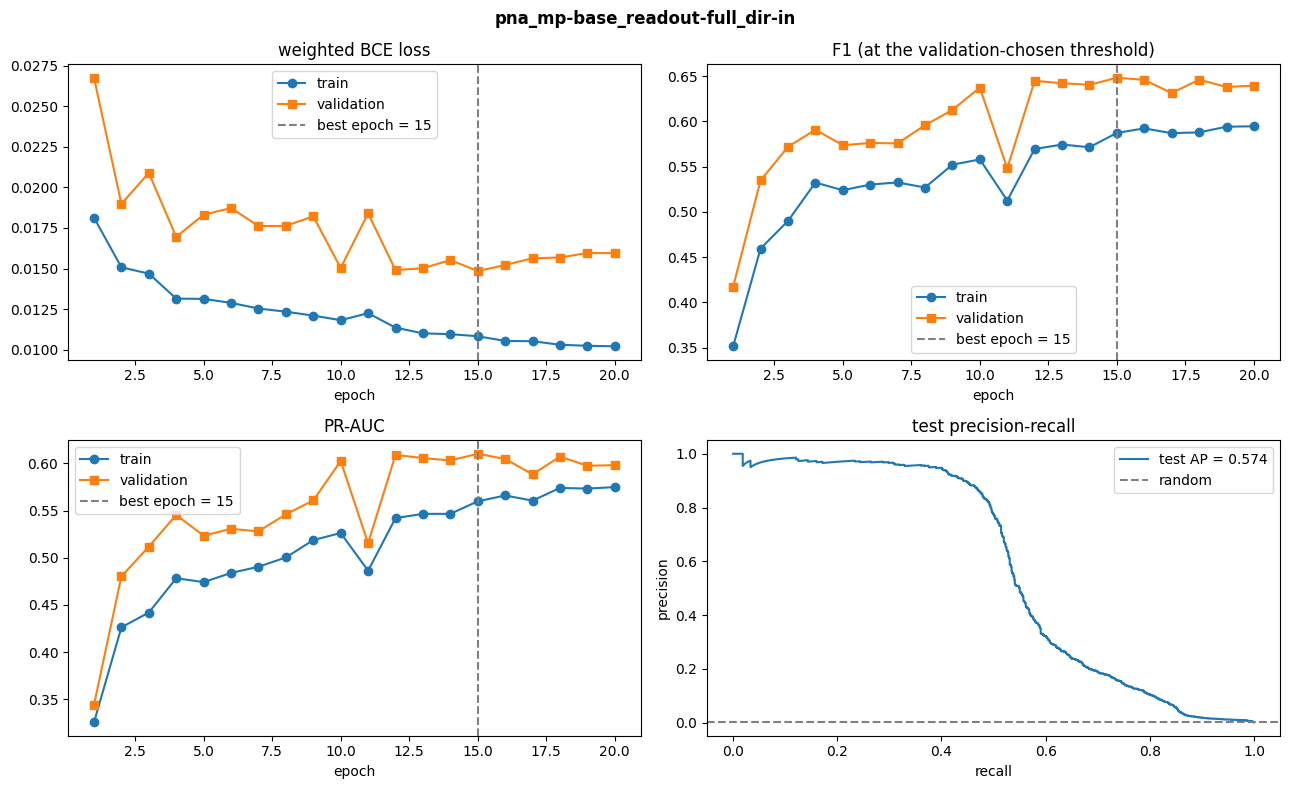

=== pna_mp-base_readout-gfp_dir-in ===
MP edge features: 20 | readout edge features: 61
total params: 604,929 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0105 / 0.0164 | F1 0.5774 / 0.6163 @ 0.729 | PR-AUC 0.5653 / 0.5788 | 183s | RAM 8.6GB   (train / val)
best validation F1 0.6214 at epoch 16 (threshold 0.764)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5644  0.6214  0.5753
precision          0.8454  0.8336  0.7507
recall             0.4236  0.4954  0.4663
pr_auc             0.5543  0.5816  0.5397
roc_auc            0.9910  0.9823  0.9817
precision_at_5pct  0.0140  0.0183  0.0195
recall_at_5pct     0.9290  0.8577  0.8679
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-base_readout-gfp_dir-in/predictions.csv


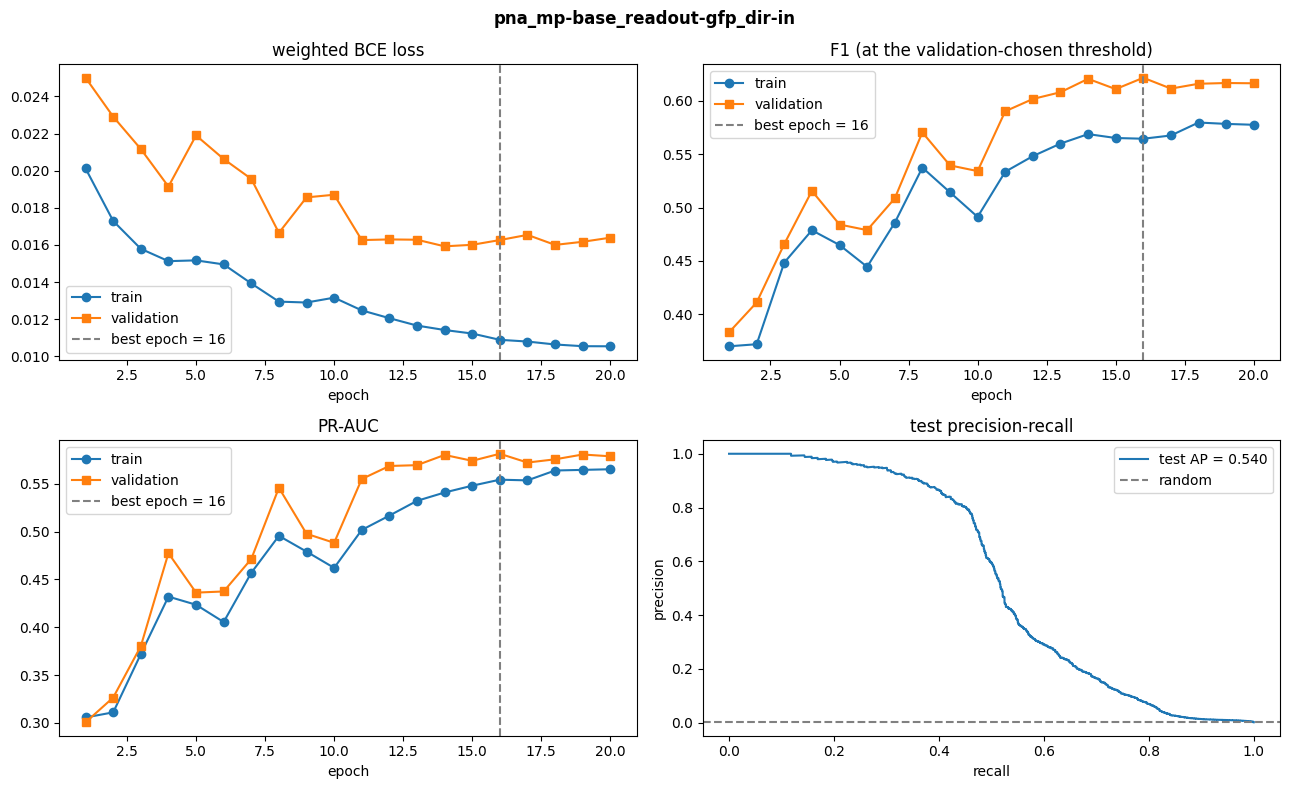

=== pna_mp-none_readout-gfp_dir-in ===
MP edge features: 0 | readout edge features: 61
total params: 566,785 | architecture-invariant: 427,265


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0179 / 0.0245 | F1 0.3400 / 0.3939 @ 0.566 | PR-AUC 0.2910 / 0.3213 | 146s | RAM 7.7GB   (train / val)
best validation F1 0.4061 at epoch 14 (threshold 0.562)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.3403  0.4061  0.3563
precision          0.6444  0.5210  0.3531
recall             0.2312  0.3327  0.3596
pr_auc             0.2821  0.3249  0.2898
roc_auc            0.9692  0.9628  0.9592
precision_at_5pct  0.0120  0.0169  0.0178
recall_at_5pct     0.7980  0.7939  0.7927
predictions: 5,077,237 rows -> /kaggle/working/Outputs/PNA/pna_mp-none_readout-gfp_dir-in/predictions.csv


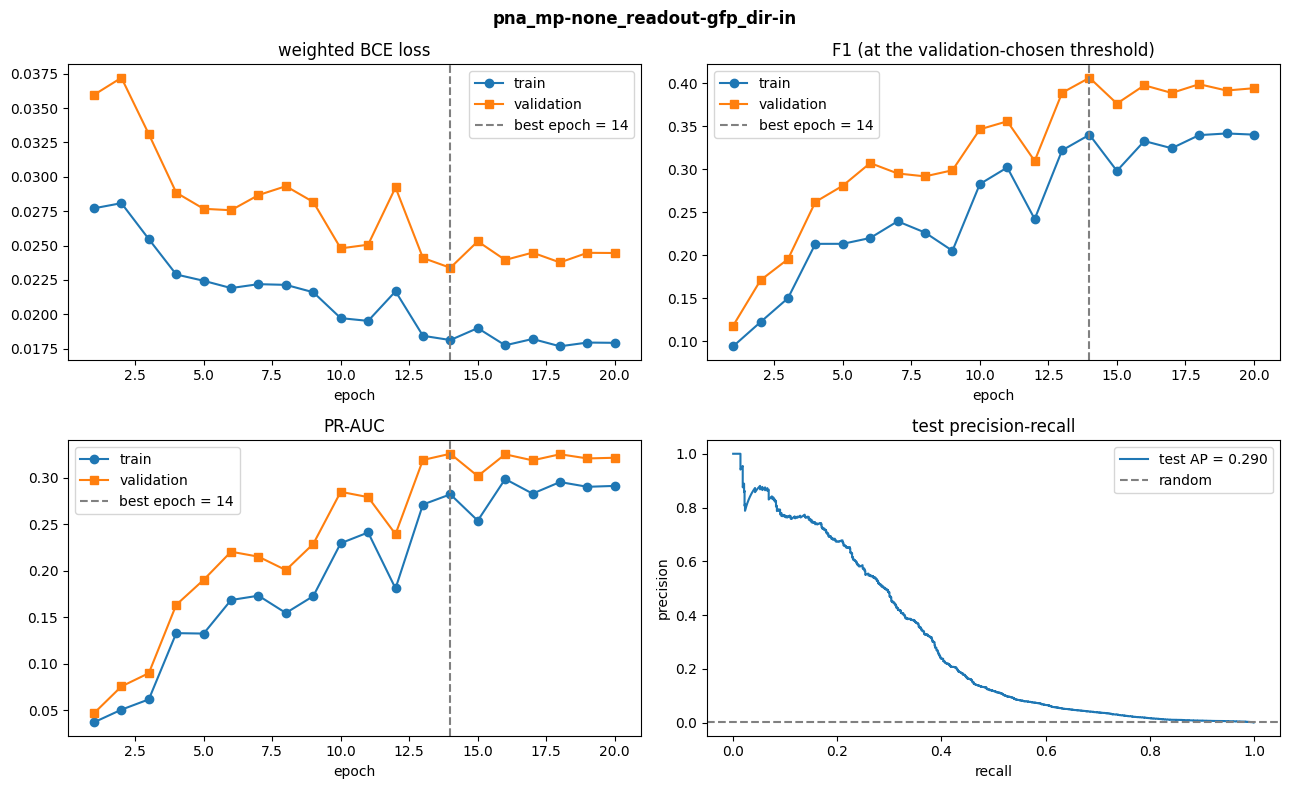

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(OPERATOR, cfg, graphs, col_sets, node_dim, OUT_ROOT,
                                    MP_DIRECTION, TEMPORAL_SAMPLING))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary.csv` holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`.
- `invariant_params` must be identical in every row (asserted).

In [7]:
summary = core.summarize_batch(rows, OUT_ROOT)
summary[core.DISPLAY_COLS].round(4)

7 runs -> /kaggle/working/Outputs/PNA/batch_summary.csv | invariant_params = 427,265 in every row


,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,pna_mp-none_readout-base_dir-in,12,0.4897,0.4909,0.4523,0.5997,0.3631,0.3892,0.0193,0.8556,561537,427265
1,pna_mp-base_readout-base_dir-in,14,0.6316,0.6508,0.6138,0.7764,0.5074,0.5783,0.0198,0.8810,599681,427265
2,pna_mp-none_readout-full_dir-in,14,0.4532,0.5737,0.5117,0.6797,0.4103,0.4720,0.0195,0.8653,569345,427265
3,pna_mp-full_readout-full_dir-in,15,0.6989,0.6482,0.6167,0.8556,0.4821,0.5754,0.0200,0.8880,623105,427265
4,pna_mp-base_readout-full_dir-in,15,0.7112,0.6481,0.6111,0.8003,0.4943,0.5739,0.0201,0.8924,607489,427265
5,pna_mp-base_readout-gfp_dir-in,16,0.7639,0.6214,0.5753,0.7507,0.4663,0.5397,0.0195,0.8679,604929,427265
6,pna_mp-none_readout-gfp_dir-in,14,0.5615,0.4061,0.3563,0.3531,0.3596,0.2898,0.0178,0.7927,566785,427265


## 6. Download

- Zip `OUT_ROOT`; extract into `Outputs/PNA/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive(f'/kaggle/working/Outputs_{OPERATOR.upper()}', 'zip', OUT_ROOT)

'/kaggle/working/Outputs_PNA.zip'